# Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import folium

In [32]:
df=pd.read_csv('datasets/Meteorite_Landings.csv')
df.head(15)


,Name,ID,NameType,Classification,Mass,Fall,Year,Coordinates
0,Aachen,1,Valid,L5,"Quantity[21, ""Grams""]",Fell,"DateObject[{1880}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{50.775, 6.08333}]"
1,Aarhus,2,Valid,H6,"Quantity[720, ""Grams""]",Fell,"DateObject[{1951}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{56.18333, 10.23333}]"
2,Abee,6,Valid,EH4,"Quantity[107000, ""Grams""]",Fell,"DateObject[{1952}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{54.21667, -113.}]"
3,Acapulco,10,Valid,Acapulcoite,"Quantity[1914, ""Grams""]",Fell,"DateObject[{1976}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{16.88333, -99.9}]"
4,Achiras,370,Valid,L6,"Quantity[780, ""Grams""]",Fell,"DateObject[{1902}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-33.16667, -64.95}]"
5,Adhi Kot,379,Valid,EH4,"Quantity[4239, ""Grams""]",Fell,"DateObject[{1919}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{32.1, 71.8}]"
6,Adzhi-Bogdo (stone),390,Valid,LL3-6,"Quantity[910, ""Grams""]",Fell,"DateObject[{1949}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{44.83333, 95.16667}]"
7,Agen,392,Valid,H5,"Quantity[30000, ""Grams""]",Fell,"DateObject[{1814}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{44.21667, 0.61667}]"
8,Aguada,398,Valid,L6,"Quantity[1620, ""Grams""]",Fell,"DateObject[{1930}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-31.6, -65.23333}]"
9,Aguila Blanca,417,Valid,L,"Quantity[1440, ""Grams""]",Fell,"DateObject[{1920}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-30.86667, -64.55}]"


Missing value detection

In [33]:
df=df.replace('Missing["NotAvailable"]', np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            45716 non-null  object
 1   ID              45716 non-null  int64 
 2   NameType        45716 non-null  object
 3   Classification  45716 non-null  object
 4   Mass            45585 non-null  object
 5   Fall            45716 non-null  object
 6   Year            45424 non-null  object
 7   Coordinates     32187 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.8+ MB


In [34]:
df.head(15)

,Name,ID,NameType,Classification,Mass,Fall,Year,Coordinates
0,Aachen,1,Valid,L5,"Quantity[21, ""Grams""]",Fell,"DateObject[{1880}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{50.775, 6.08333}]"
1,Aarhus,2,Valid,H6,"Quantity[720, ""Grams""]",Fell,"DateObject[{1951}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{56.18333, 10.23333}]"
2,Abee,6,Valid,EH4,"Quantity[107000, ""Grams""]",Fell,"DateObject[{1952}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{54.21667, -113.}]"
3,Acapulco,10,Valid,Acapulcoite,"Quantity[1914, ""Grams""]",Fell,"DateObject[{1976}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{16.88333, -99.9}]"
4,Achiras,370,Valid,L6,"Quantity[780, ""Grams""]",Fell,"DateObject[{1902}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-33.16667, -64.95}]"
5,Adhi Kot,379,Valid,EH4,"Quantity[4239, ""Grams""]",Fell,"DateObject[{1919}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{32.1, 71.8}]"
6,Adzhi-Bogdo (stone),390,Valid,LL3-6,"Quantity[910, ""Grams""]",Fell,"DateObject[{1949}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{44.83333, 95.16667}]"
7,Agen,392,Valid,H5,"Quantity[30000, ""Grams""]",Fell,"DateObject[{1814}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{44.21667, 0.61667}]"
8,Aguada,398,Valid,L6,"Quantity[1620, ""Grams""]",Fell,"DateObject[{1930}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-31.6, -65.23333}]"
9,Aguila Blanca,417,Valid,L,"Quantity[1440, ""Grams""]",Fell,"DateObject[{1920}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-30.86667, -64.55}]"


In [35]:
df['Mass'].describe()

count                      45585
unique                     12576
top       Quantity[1.3, "Grams"]
freq                         171
Name: Mass, dtype: object

In [36]:
df['Year'].describe()

count                                            45424
unique                                             264
top       DateObject[{2003}, "Year", "Gregorian", -5.]
freq                                              3323
Name: Year, dtype: object

In [37]:
df['Coordinates'].describe()

count                              32187
unique                             17099
top       GeoPosition[{-71.5, 35.66667}]
freq                                4761
Name: Coordinates, dtype: object

In [38]:
print(df['Coordinates'].isna().sum())
print(df['Coordinates'].isnull().mean()*100)

13529
29.59357774083472


In [39]:
print(df['Year'].isna().sum())
print(df['Year'].isnull().mean()*100)

292
0.6387260477732085


In [40]:
print(df['Mass'].isna().sum())
print(df['Mass'].isnull().mean()*100)

131
0.28655175430921337


# Cleanup and Preparation

Dropping rows having Null in Mass and Year column

In [41]:
df = df.dropna(subset=['Mass', 'Year'])
df.reset_index(drop=True, inplace=True)

### Cleaning Mass Column

Converting Mass values from string to integer

In [42]:
df["Mass_int"] = df["Mass"].str.extract(r'Quantity\[(\d+)', expand=False)
df["Mass_int"] = pd.to_numeric(df["Mass_int"], errors="coerce")

print(df[["Mass", "Mass_int"]].head())


                        Mass  Mass_int
0      Quantity[21, "Grams"]        21
1     Quantity[720, "Grams"]       720
2  Quantity[107000, "Grams"]    107000
3    Quantity[1914, "Grams"]      1914
4     Quantity[780, "Grams"]       780


Checking if all mass units are same

In [43]:
df["Mass_unit"] = df["Mass"].str.extract(r'Quantity\[\s*[\d.]+\s*,\s*"?([A-Za-z% ]+)"?\s*\]', expand=False)
print(df['Mass_unit'].value_counts())

Mass_unit
Grams    45309
Name: count, dtype: int64


In [44]:
incorrectmass=(df['Mass_int']<0).sum()
print(incorrectmass)

0


### Cleaning Year column

Extracting year in integer

In [45]:
df['Year_int'] = df['Year'].str.extract(r'DateObject\[\{(\d+)\}', expand=False)
df['Year_int'] = pd.to_numeric(df['Year_int'], errors='coerce')


Checking if all other units are same

In [46]:
all_gregorian = df['Year'].str.contains('Gregorian').all()
print("Are all values gregrian?\n", all_gregorian)

all_year=df['Year'].str.contains('Year').all()
print("Are all values year?\n", all_year)

all_minus5 = df['Year'].str.contains('-5\.').all()
print("Are all values -5?\n", all_minus5)


Are all values gregrian?
 True
Are all values year?
 True
Are all values -5?
 True


In [47]:
incorrectyear=(df['Year_int']<0).sum()
print(incorrectyear)

0


### Cleaning Coordinates column

Extracting coordinates in integer

In [48]:
df['Latitude'] = df['Coordinates'].str.extract(r'GeoPosition\[\{\s*(-?\d+(?:\.\d+)?)')
df['Longitude'] = df['Coordinates'].str.extract(r'GeoPosition\[\{\s*-?\d+(?:\.\d*)?\s*,\s*(-?\d+(?:\.\d*)?)', expand=False)

df['Latitude']=pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude']=pd.to_numeric(df['Longitude'], errors='coerce')

df[['Coordinates', 'Latitude', 'Longitude']].head()

,Coordinates,Latitude,Longitude
0,"GeoPosition[{50.775, 6.08333}]",50.77500,6.08333
1,"GeoPosition[{56.18333, 10.23333}]",56.18333,10.23333
2,"GeoPosition[{54.21667, -113.}]",54.21667,-113.00000
3,"GeoPosition[{16.88333, -99.9}]",16.88333,-99.90000
4,"GeoPosition[{-33.16667, -64.95}]",-33.16667,-64.95000


In [49]:
incorrectlat=(df['Latitude']<-90).sum()
incorrectlat+=(df['Latitude']>90).sum()

incorrectlong=(df['Longitude']<-180).sum()
incorrectlong+=(df['Longitude']>180).sum()


print(incorrectlat,incorrectlong)

0 0


In [50]:
df[['Mass_int','Mass_unit','Year_int','Latitude','Longitude']].info()
df[['Mass','Year','Coordinates']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45309 entries, 0 to 45308
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Mass_int   45309 non-null  int64  
 1   Mass_unit  45309 non-null  object 
 2   Year_int   45309 non-null  int64  
 3   Latitude   31929 non-null  float64
 4   Longitude  31929 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45309 entries, 0 to 45308
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Mass         45309 non-null  object
 1   Year         45309 non-null  object
 2   Coordinates  31929 non-null  object
dtypes: object(3)
memory usage: 1.0+ MB


# Analysis and Insights

### Heaviest Meteorite

In [51]:
heaviest_meteorites = df.sort_values(by='Mass_int', ascending=False).head(10).reset_index(drop=True)

print("Top 10 Heaviest Meteorites are:")
for row in heaviest_meteorites.iterrows():
    print(f"Name: {row[1]['Name']}, Mass: {row[1]['Mass_int']}")


Top 10 Heaviest Meteorites are:
Name: Hope, Mass: 60000000
Name: Catalina 011, Mass: 58200000
Name: Catalina 003, Mass: 50000000
Name: Catalina 008, Mass: 30000000
Name: Asuka 8602, Mass: 28000000
Name: Glorieta Mountain, Mass: 26000000
Name: Colorado Springs, Mass: 24300000
Name: Mundrabilla 005, Mass: 24000000
Name: Sinai, Mass: 23000000
Name: Bates Nunataks A78005, Mass: 22000000


### Fell vs Found

In [52]:
fall_counts = df['Fall'].value_counts()
print(fall_counts)


Fall
Found    44234
Fell      1075
Name: count, dtype: int64


### Average Mass for the Most Common Classifications

In [53]:

avg_mass_by_class = df.groupby('Classification')['Mass_int'].mean().sort_values(ascending=False)


common_classes = df['Classification'].value_counts().head(10).index
avg_mass_common = avg_mass_by_class.loc[common_classes]

print(avg_mass_common)


Classification
L6      1451.317343
H5      2156.610814
L5      1797.123870
H6       862.785651
H4       999.837515
LL5      464.333575
LL6      692.772705
L4      1643.889803
H4/5    1610.957647
CM2      368.636804
Name: Mass_int, dtype: float64


### Time-Based Analysis (By Decade)

In [54]:
df['Decade'] = (df['Year_int'] // 10) * 10
df['Decade'].head(10)

0    1880
1    1950
2    1950
3    1970
4    1900
5    1910
6    1940
7    1810
8    1930
9    1920
Name: Decade, dtype: int64

In [55]:
decade_trends = df.groupby('Decade').size().sort_values(ascending=False)
decade_trends.head()

Decade
2000    17739
1990    11586
1980     6816
1970     4962
2010     1963
dtype: int64

### NumPy Operations on Mass

In [56]:
mass_arr = df['Mass_int'].to_numpy()
mean_mass = np.mean(mass_arr)
median_mass = np.median(mass_arr)
std_mass = np.std(mass_arr)
sum_mass = np.sum(mass_arr)
max_mass = np.max(mass_arr)

print("Mean mass (kg):", mean_mass)
print("Median mass (kg):", median_mass)
print("Standard Deviation (kg):", std_mass)
print("Total mass (kg):", sum_mass)
print("Maximum mass (kg):", max_mass)

Mean mass (kg): 13314.902734556048
Median mass (kg): 32.0
Standard Deviation (kg): 576720.420424452
Total mass (kg): 603284928
Maximum mass (kg): 60000000


# Visualization

### Count of “Fell” vs “Found” Meteorites

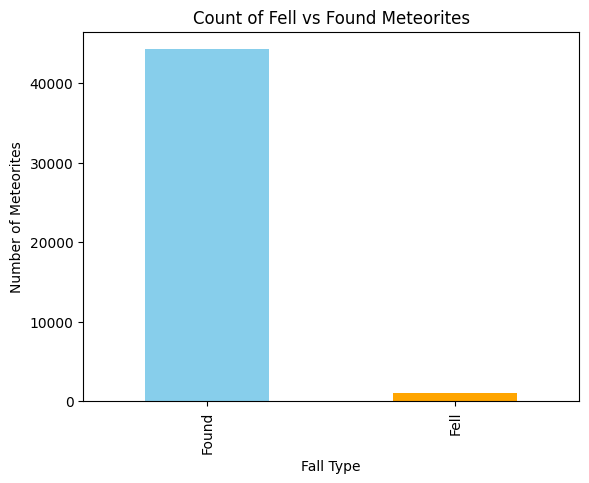

In [57]:
df['Fall'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Count of Fell vs Found Meteorites')
plt.xlabel('Fall Type')
plt.ylabel('Number of Meteorites')
plt.show()


### Average Meteorite Mass by Classification

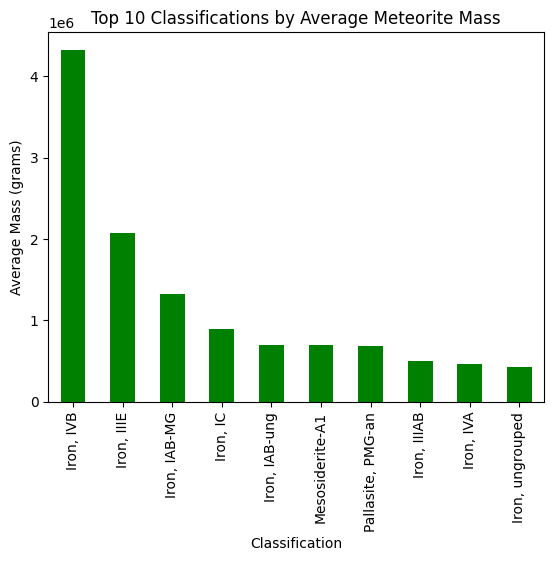

In [58]:
avg_mass = df.groupby('Classification')['Mass_int'].mean().sort_values(ascending=False).head(10)

avg_mass.plot(kind='bar', color='green')
plt.title('Top 10 Classifications by Average Meteorite Mass')
plt.xlabel('Classification')
plt.ylabel('Average Mass (grams)')
plt.show()


### Discovery Trends Over Time (by Decade)

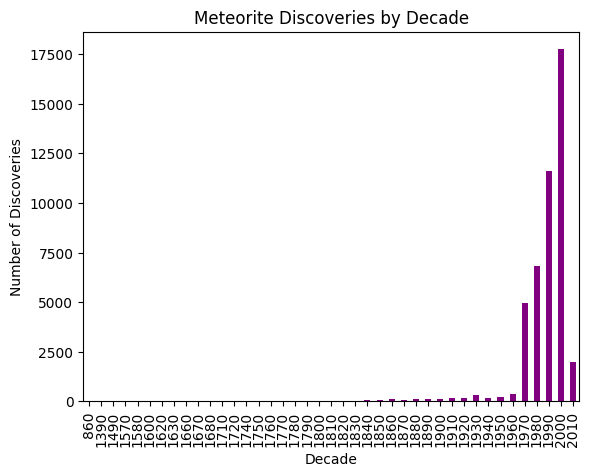

In [59]:
df.groupby('Decade').size().plot(kind='bar', color='purple')
plt.title('Meteorite Discoveries by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Discoveries')
plt.show()


### Average Meteorite Mass per Decade

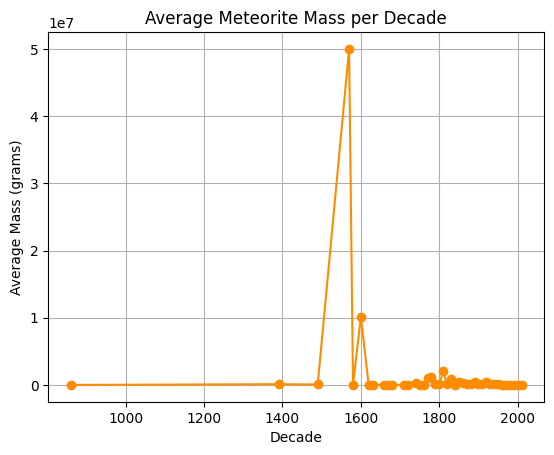

In [60]:
df.groupby('Decade')['Mass_int'].mean().plot(kind='line', marker='o', color='darkorange')
plt.title('Average Meteorite Mass per Decade')
plt.xlabel('Decade')
plt.ylabel('Average Mass (grams)')
plt.grid(True)
plt.show()
